# MLE-KG estimator v.s. Hill estimator and Rank-size estimator

## log normal transition

Code updates (relative to version R2):

1. Implemented a full joint search after profiling, to refine the estimates of (b,μ,σ).

2. Keep only the leave-one-out (LOO) option for simplicity.

3. Adjusted parameter grids: updated alpha_list and sigma_list.

4. Added a runtime measurement to report total execution time.

5. Reduced the burn-in period from 10,000 to 2,000 iterations.

### Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, root_scalar, minimize
import time

# -------------------------
# Simulation configuration
# -------------------------

alpha_list = (1.2, 1.35, 1.5)                              # 1.2-1.5 preferred
sigma_list = (0.4, 0.55, 0.7, 0.85, 1.0)  # from 0.45 to 0.70 preferred
b_list=(0.1, 1.0)
n=2000
burn_in = 2000
R=500
seed=0

### Functions for DGP

In [2]:
# -------------------------
# X generate process
# -------------------------

def draw_x0(n, rng):
    # positive covariate, e.g. lognormal
    return np.exp(rng.normal(0.0, 0.5, size=n))

def draw_y_given_x(x, b, mu, sigma, rng):
    z = rng.standard_normal(size=len(x))
    y = b + x * np.exp(mu + sigma * z)
    return y

def draw_sample(n, b, mu, sigma, burn_in, rng):
    x = draw_x0(n, rng)
    # burn-in to get close to stationarity
    for _ in range(burn_in):
        x = draw_y_given_x(x, b, mu, sigma, rng)
    y = draw_y_given_x(x, b, mu, sigma, rng)
    return x, y

### Functions for Different Estimators

In [3]:

# -------------------------
# MLE machinery
# -------------------------

# =========================================================
# Model: y_i = b + x_i * exp( mu + sigma * Z_i ), Z_i ~ N(0,1)
# Likelihood: f(x,y) = [1/sigma] * [1/(y-b)] * phi( (ln((y-b)/x)-mu)/sigma ), y > b
# Log-likelihood:
#   ℓ(b, μ, σ) = Σ_i [ -ln σ - ln(y_i-b) - 0.5 ln(2π) - (ln((y_i-b)/x_i)-μ)^2 / (2 σ^2) ]
# Closed-form given b:
#   r_i(b)  = ln((y_i - b)/x_i)
#   μ̂(b)   = mean r_i(b)
#   σ̂^2(b) = mean (r_i(b) - μ̂(b))^2
# FOC(b) profiled: Σ [ 1/(y_i-b) * { 1 + (r_i - μ̂(b))/σ̂^2(b) } ] = 0
# =========================================================


def safe_r(y, x, b):
    z = y - b
    if np.any(z <= 0):
        raise ValueError("b must be strictly less than all y_i.")
    return np.log(z) - np.log(x)

def mu_sig2_hat(y, x, b):
    r = safe_r(y, x, b)
    mu = r.mean()
    sig2 = ((r - mu)**2).mean()
    return mu, max(sig2, 1e-16)

def loglik_forward(y, x, b, mu, sig2):
    r = safe_r(y, x, b)
    n = r.size
    return - n * 0.5 * np.log(2*np.pi) - 0.5 * n * np.log(max(sig2, 1e-16)) \
           - np.sum(np.log(y - b)) - (1.0/(2*max(sig2, 1e-16))) * np.sum((r - mu)**2)

def cond_density_matrix(y_vec, x_vec, b, mu, sig2):
    """Lognormal density of Y|X=x."""
    y = np.asarray(y_vec, dtype=float)
    x = np.asarray(x_vec, dtype=float)
    if np.any(y <= b):
        raise ValueError("b must be strictly less than all y_i.")
    sigma = np.sqrt(max(sig2, 1e-16))
    t = y - b                             # length n
    log_t = np.log(t)                     # (n,)
    log_x = np.log(np.maximum(x, 1e-16))    # (n,)
    
    # Broadcast to (n,n): logratio[i,j] = log_t[i] - log_x[j] - mu
    logratio = log_t[:, None] - log_x[None, :] - mu
    
    const = 1.0 / (sigma * np.sqrt(2*np.pi))       # scalar
    D = const * 1.0 / np.maximum(t[:, None], 1e-16) * np.exp( -0.5 * logratio**2 / max(sig2, 1e-16))  # (n,n)
    return D

def leave_one_out_density(x_vec, b, mu, sig2):
    """
    For each i, compute LOO average of f(Y=x_i | X=X_j) over j != i.
    Returns an array of length n aligned with X.
    """
    x_vec = np.asarray(x_vec, dtype=float)
    n = len(x_vec)
    if n < 2:
        raise ValueError("Need at least n=2 for leave-one-out.")
    # Build the n x n density matrix at y_i = x_i against all x_j
    D = cond_density_matrix(x_vec, x_vec, b, mu, sig2)   # D[i,j] = f(X_i | X_j)
    # Leave-one-out row means: subtract diagonal, divide by (n-1)
    column_sums = D.sum(axis=1)
    diag = np.diag(D)
    loo = (column_sums - diag) / (n - 1)
    return np.maximum(loo, 1e-300)

def loglik_marginal(x, b, mu, sig2):
    """Compute log likelihood of marginal distributions over X_i's"""
    return np.sum(np.log(leave_one_out_density(x, b, mu, sig2)))

def loglik_profile(y, x, b):
    mu, sig2 = mu_sig2_hat(y, x, b)
    return loglik_forward(y, x, b, mu, sig2) + loglik_marginal(x, b, mu, sig2)

def total_loglik(y, x, b, mu, sig2):
    """Full objective: conditional + marginal log-likelihood."""
    return loglik_forward(y, x, b, mu, sig2) + loglik_marginal(x, b, mu, sig2)

def joint_optimize_local(y, x, b0, mu0, sig20,
                         w_b=None, w_mu=None, w_logsig2=1.0,
                         method="L-BFGS-B", verbose=False):
    """
    Local 3D joint optimization of (b, mu, sig2) around (b0, mu0, sig20).

    Parameters
    ----------
    y, x : arrays
    b0, mu0, sig20 : starting values (from profiling)
    w_b : half-width for b search window (if None, set adaptively)
    w_mu : half-width for mu window (if None, set adaptively)
    w_logsig2 : half-width for log(sig2) window (default ±1 => ~x/e..x*e)
    method : scipy minimize method
    """
    y = np.asarray(y, float); x = np.asarray(x, float)
    n = len(y)
    tiny = 1e-12

    span = float(np.std(y))
    b_hi = float(np.min(y)) - 1e-6
    b_lo = float(np.min([np.min(y), np.min(x)])) - max(1.0, 5.0 * span)

    # Local windows (adjacent to the profiled solution)
    if w_b is None:
        w_b = 0.25 * span + 1e-3
    if w_mu is None:
        # a mild window that scales with sigma; add cushion
        w_mu = 3.0 * np.sqrt(max(sig20, 1e-16)) + 0.5
    if w_logsig2 is None:
        w_logsig2 = 1.0

    # Bounds
    b_lower = max(b_lo, b0 - w_b)
    b_upper = min(b_hi - tiny, b0 + w_b)
    if not (b_lower < b_upper):
        # If window degenerates, relax it toward the feasible region
        b_lower = b_lo
        b_upper = b_hi - tiny

    mu_lower = mu0 - w_mu
    mu_upper = mu0 + w_mu

    log_s2_0 = np.log(max(sig20, 1e-16))
    log_s2_lower = log_s2_0 - w_logsig2
    log_s2_upper = log_s2_0 + w_logsig2

    bounds = [(b_lower, b_upper), (mu_lower, mu_upper), (log_s2_lower, log_s2_upper)]

    # Objective in (b, mu, log_s2)
    def neg_obj(theta):
        b, mu, log_s2 = theta
        sig2 = float(np.exp(log_s2))
        try:
            val = total_loglik(y, x, b, mu, sig2)
            return -val
        except Exception:
            # Infeasible combos (e.g., y-b <= 0) -> penalize heavily
            return 1e50

    theta0 = np.array([b0, mu0, log_s2_0], dtype=float)
    res = minimize(neg_obj, theta0, method=method, bounds=bounds)

    b_star, mu_star, log_s2_star = res.x
    sig2_star = float(np.exp(log_s2_star))
    out = {
        "success": bool(res.success),
        "message": res.message,
        "nfev": res.nfev,
        "status": res.status,
        "b_hat_joint": float(b_star),
        "mu_hat_joint": float(mu_star),
        "sigma_hat_joint": float(np.sqrt(sig2_star)),
        "sig2_hat_joint": float(sig2_star),
        "ll_full_joint": float(total_loglik(y, x, b_star, mu_star, sig2_star)),
    }
    if verbose:
        print(out)
    return out

def mle_single(x, y):
    """
    1) Profile: maximize in b using mu_sig2_hat(b).
    2) Local 3D joint polish near (b_hat, mu_hat(b_hat), sig2_hat(b_hat)).
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    
    # ----- Step 1: profile to get b_hat -----
    xymin = min(float(np.min(y)), float(np.min(x)))
    span = float(np.std(y))
    b_hi = xymin - 1e-6
    b_lo = xymin - max(1.0, 5.0 * span)

    # maximize log-likelihood in b
    prof = minimize_scalar(lambda b: -loglik_profile(y, x, b),
                          bounds=(b_lo, b_hi), method="bounded")
    b_hat = float(prof.x)
    mu_hat, sig2_hat = mu_sig2_hat(y, x, b_hat)
    
    # Diagnostics at profiled solution
    ll_fwd = loglik_forward(y, x, b_hat, mu_hat, sig2_hat)
    ll_mgnl = loglik_marginal(x, b_hat, mu_hat, sig2_hat)

    # ----- Step 2: local 3D joint optimization -----
    joint = joint_optimize_local(
        y, x,
        b0=b_hat, mu0=mu_hat, sig20=sig2_hat,
        w_b=0.5 * span + 1e-3,     # can tighten/loosen these windows
        w_mu=None,                 # auto from sigma^2
        w_logsig2=1.0,            # ±1 on log(sig2) ~ factor e
        method="L-BFGS-B"
    )

    # Alpha based on the *profiled* (mu_hat, sig2_hat) for continuity with your code
    alpha_hat_prof = -2.0 * mu_hat / max(sig2_hat, 1e-16)
    # And alpha based on the joint solution as well
    alpha_hat_joint = -2.0 * joint["mu_hat_joint"] / max(joint["sig2_hat_joint"], 1e-16)

    return {
        # Profiled solution
        "b_hat_profile": b_hat,
        "mu_hat_profile": mu_hat,
        "sigma_hat_profile": float(np.sqrt(sig2_hat)),
        "ll_fwd_profile": ll_fwd,
        "ll_mgnl_profile": ll_mgnl,
        "ll_full_profile": ll_fwd + ll_mgnl,
        "alpha_hat_profile": alpha_hat_prof,

        # Joint-polished solution
        **joint,
        "alpha_hat_joint": alpha_hat_joint
    }

# -------------------------
# Hill estimator for Pareto tail
#   Given positive tail sample T, sort ascending:
#   X_(1) <= ... <= X_(n). For k top order stats:
#   u = X_(n-k)
#   Hill alpha_hat(k) = [ (1/k) * sum_{i=1..k} ln( X_(n-i+1) / u ) ]^{-1}
# -------------------------

def hill_alpha(T, k):
    T = np.asarray(T, float)
    if np.any(T <= 0): raise ValueError("Tail sample must be strictly positive for Hill.")
    T_sorted = np.sort(T)
    n = T_sorted.size
    if not (1 <= k < n):
        raise ValueError("k must be between 1 and n-1.")
    u = T_sorted[n - k - 1]
    top = T_sorted[(n - k):]
    return 1.0 / np.mean(np.log(top / u)), u

def hill_plot(T, k_min=5, k_max=None, mark_k=None, ax=None, title="Hill plot"):
    T = np.asarray(T, float)
    n = T.size
    if k_max is None:
        k_max = max(10, n // 2)
    ks = np.arange(k_min, k_max + 1)
    alphas = []
    for k in ks:
        a, _ = hill_alpha(T, k)
        alphas.append(a)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(ks, alphas, lw=1.8)
    if mark_k is not None:
        a_star, _ = hill_alpha(T, mark_k)
        ax.axvline(mark_k, ls='--', c='k', alpha=0.6)
        ax.axhline(a_star, ls='--', c='k', alpha=0.6)
        ax.plot([mark_k], [a_star], 'ko')
    ax.set_xlabel("k (number of top order statistics)")
    ax.set_ylabel(r"$\hat \alpha_{\text{Hill}}(k)$")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    return ks, np.array(alphas)

# ---------------------------------------------------------
# Simple k-selection: minimize KS distance between fitted Pareto and empirical tail
# ---------------------------------------------------------

def ks_distance_pareto(T, k, u):
    T = np.sort(np.asarray(T, float))
    n = T.size
    tail = T[(n - k):]
    a_hat = 1.0 / np.mean(np.log(tail / u))
    # Empirical CDF on tail values
    F_emp = np.arange(1, k + 1) / k
    # Pareto model survival: P(X > t | X > u) = (u/t)^alpha for t >= u
    # => conditional CDF on tail: 1 - (u/t)^alpha
    model = 1.0 - (u / tail)**a_hat
    return np.max(np.abs(F_emp - model))

def choose_k_by_KS(T, k_min=5, k_max=None):
    T = np.asarray(T, float)
    n = T.size
    if k_max is None:
        k_max = max(10, n // 2)
    best = None
    for k in range(k_min, k_max + 1):
        a_hat, u = hill_alpha(T, k)
        d = ks_distance_pareto(T, k, u)
        if (best is None) or (d < best[0]):
            best = (d, k, a_hat, u)
    return {"k": best[1], "alpha": best[2], "u": best[3], "KS": best[0]}

# ---------------------------------------------------------
# Tail regression alpha:  ln S(x) ≈ ln c − α ln x 
# Conditional tail: for x ≥ u, S(X≥x|X≥u) = (u/x)^α  ⇒ ln S = α ln(u/x)
#     Use top-k order stats, S_i = i/k  for the tail only; regress ln S_i on ln(u/x_i).
# ---------------------------------------------------------

def tail_regression_alpha(T, k):
    T = np.sort(np.asarray(T, float))
    n = T.size
    tail = T[(n - k):]
    u = tail[0]
    x = np.log(u / tail)                    # regressors
    S = (np.arange(k, 0, -1)) / k           # empirical conditional survival in tail
    y = np.log(S)                           # response
    # Linear fit y = a1 * x + a0  (slope should be α, a0 ideally 0)
    a1, a0 = np.polyfit(x, y, 1)
    return {
        "a1_hat": a1,
        "a0_hat": a0
    }


In [4]:
b=0.1
mu=-0.15
sigma = 0.5
rng = np.random.default_rng(0)
x, y = draw_sample(n, b, mu, sigma, burn_in, rng)
m = cond_density_matrix(x, x, b, mu, sigma**2)

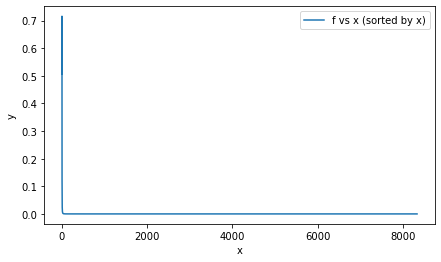

In [5]:
f = m.mean(axis=0)
idx = np.argsort(x)
plt.figure(figsize=(7,4))
plt.plot(x[idx], f[idx], '-', label="f vs x (sorted by x)")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [6]:
mle_single(x, y)

{'b_hat_profile': 0.10416260578948681,
 'mu_hat_profile': -0.16076408431436157,
 'sigma_hat_profile': 0.508975328650117,
 'll_fwd_profile': -1469.1795424268855,
 'll_mgnl_profile': -3075.5935635986048,
 'll_full_profile': -4544.77310602549,
 'alpha_hat_profile': 1.2411536931969274,
 'success': True,
 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH',
 'nfev': 48,
 'status': 0,
 'b_hat_joint': 0.10420059049631264,
 'mu_hat_joint': -0.15744659190634758,
 'sigma_hat_joint': 0.5107071597056718,
 'sig2_hat_joint': 0.26082180297463453,
 'll_full_joint': -4544.697095498723,
 'alpha_hat_joint': 1.2073115829328087}

### Functions for Monte Carlo Simulations

In [7]:
# -------------------------
# Monte Carlo experiment
# -------------------------

def one_rep(alpha, sigma, b, n, burn_in, rng):
    mu = - alpha * sigma ** 2 /2
    x, y = draw_sample(n, b, mu, sigma, burn_in, rng)
    # --- Hill: choose k, compute alpha ---
    sel = choose_k_by_KS(x, k_min=10, k_max=min(300, len(x)-5))
    # --- MLE ---
    est = mle_single(x, y)
    # --- rank-size estimator (only consistent when tail Pareto; not for lognormal model)---
    treg = tail_regression_alpha(x, sel["k"])
    return {
        "b_mle": est["b_hat_joint"],
        "mu_mle": est["mu_hat_joint"],
        "sig_mle": est["sigma_hat_joint"],
        "alpha_mle": est["alpha_hat_joint"],
        "k_star": sel["k"],
        "alpha_hill": sel["alpha"],
        "alpha_treg": treg["a1_hat"]
    }


def run_simulation(alpha_list, sigma_list, b_list, n, burn_in, R, seed):
    master = np.random.default_rng(seed)
    results = {}
    
    for alpha in alpha_list:
        for b in b_list:
            for sigma in sigma_list:
                mu = - alpha * sigma ** 2 /2

                # Collect rep-by-rep dicts
                b_mle, mu_mle, sig_mle = [], [], []
                alpha_mle, k_star, alpha_hill, alpha_treg = [], [], [], []

                for _ in range(R):
                    rng = np.random.default_rng(master.integers(2**31 - 1))  # per-rep RNG
                    rep = one_rep(alpha, sigma, b, n, burn_in, rng)

                    b_mle.append(rep["b_mle"])
                    mu_mle.append(rep["mu_mle"])
                    sig_mle.append(rep["sig_mle"])
                    alpha_mle.append(rep["alpha_mle"])
                    k_star.append(rep["k_star"])
                    alpha_hill.append(rep["alpha_hill"])
                    alpha_treg.append(rep["alpha_treg"])

                key = (alpha, b, sigma)
                results[key] = {
                    # truths for this cell
                    "true_alpha":   alpha,
                    "true_b":       b,
                    "true_sigma":   sigma,
                    "true_mu":      mu,

                    # arrays of estimates
                    "b_mle":      np.asarray(b_mle),
                    "mu_mle":     np.asarray(mu_mle),
                    "sig_mle":    np.asarray(sig_mle),
                    "alpha_mle":  np.asarray(alpha_mle),
                    "k_star":     np.asarray(k_star),
                    "alpha_hill": np.asarray(alpha_hill),
                    "alpha_treg": np.asarray(alpha_treg),
                }
    return results

def summarize_vec(x, truth, name=None):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return {"name": name, "mean": np.nan, "sd": np.nan, "bias": np.nan, "rmse": np.nan}
    err = x - float(truth)
    return {
        "name": name,
        "mean": float(np.mean(x)),
        "sd": float(np.std(x, ddof=1)),
        "bias": float(np.mean(err)),
        "rmse": float(np.sqrt(np.mean(err**2)))
    }

def summarize_results(results):
    tables = []
    for (alpha, b, sigma), d in results.items():
        truth_alpha = float(d["true_alpha"])
        truth_b     = float(d["true_b"])
        truth_sig   = float(d["true_sigma"])
        truth_mu    = float(d["true_mu"])
        
        # MLE
        s_b_mle   = summarize_vec(d["b_mle"],    truth_b,     "b_mle")
        s_mu_mle  = summarize_vec(d["mu_mle"],   truth_mu,    "mu_mle")
        s_sig_mle = summarize_vec(d["sig_mle"],  truth_sig,   "sig_mle")
        s_a_mle   = summarize_vec(d["alpha_mle"],truth_alpha, "alpha_mle")
        
        # Tail estimators
        s_hill = summarize_vec(d["alpha_hill"], truth_alpha, "alpha_hill")
        s_treg = summarize_vec(d["alpha_treg"], truth_alpha, "alpha_treg")

        # k* stats (handle NaNs)
        k_arr = np.asarray(d["k_star"], dtype=float)
        k_mean = float(np.nanmean(k_arr)) if k_arr.size else np.nan
        k_sd   = float(np.nanstd(k_arr, ddof=1)) if k_arr.size else np.nan

        tables.append({
            "b": truth_b, "mu": truth_mu, "sigma": truth_sig, "alpha": truth_alpha,
            # --- MLE ---
            "b_mle_name": s_b_mle["name"],
            "b_mle_mean": s_b_mle["mean"],   "b_mle_sd": s_b_mle["sd"],
            "b_mle_bias": s_b_mle["bias"],   "b_mle_rmse": s_b_mle["rmse"],

            "mu_mle_name": s_mu_mle["name"],
            "mu_mle_mean": s_mu_mle["mean"], "mu_mle_sd": s_mu_mle["sd"],
            "mu_mle_bias": s_mu_mle["bias"], "mu_mle_rmse": s_mu_mle["rmse"],

            "sig_mle_name": s_sig_mle["name"],
            "sig_mle_mean": s_sig_mle["mean"], "sig_mle_sd": s_sig_mle["sd"],
            "sig_mle_bias": s_sig_mle["bias"], "sig_mle_rmse": s_sig_mle["rmse"],

            "alpha_mle_name": s_a_mle["name"],
            "alpha_mle_mean": s_a_mle["mean"], "alpha_mle_sd": s_a_mle["sd"],
            "alpha_mle_bias": s_a_mle["bias"], "alpha_mle_rmse": s_a_mle["rmse"],
            
            # --- Tail estimators ---
            "k_star_name": "k_star",
            "k_star_mean": k_mean, "k_star_sd": k_sd,
            "k_star_bias": np.nan, "k_star_rmse": np.nan,

            "alpha_hill_name": s_hill["name"],
            "alpha_hill_mean": s_hill["mean"], "alpha_hill_sd": s_hill["sd"],
            "alpha_hill_bias": s_hill["bias"], "alpha_hill_rmse": s_hill["rmse"],

            "alpha_treg_name": s_treg["name"],
            "alpha_treg_mean": s_treg["mean"], "alpha_treg_sd": s_treg["sd"],
            "alpha_treg_bias": s_treg["bias"], "alpha_treg_rmse": s_treg["rmse"],
        })
    return tables


### Simulation

In [8]:
# Run it
t0 = time.perf_counter()
res = run_simulation(alpha_list, sigma_list, b_list, n, burn_in, R, seed)
table = summarize_results(res)
t1 = time.perf_counter()
print(f"Runtime: {t1 - t0:.3f} seconds")


Runtime: 25901.150 seconds


### Tables

In [9]:
# -------------------------
# Output: Tables
# -------------------------

print(f"Monte Carlo summary (n={n}, R={R}, burn_in={burn_in})")
prefixes = ["b_mle", "mu_mle", "sig_mle", "alpha_mle", "alpha_hill", "alpha_treg", "k_star"]
for tab in sorted(table, key=lambda r: (r["alpha"], r["b"], r["sigma"])):
    print("True Values (alpha={}, mu={}, sigma={}, b={})".format(tab['alpha'], tab['mu'], tab['sigma'], tab['b']))
    for prefix in prefixes:
        print("{:>10s}: mean={:+.4f}, sd={:.4f}, bias={:+.4f}, rmse={:.4f}".format(
            prefix,
            tab[f"{prefix}_mean"],
            tab[f"{prefix}_sd"],
            tab[f"{prefix}_bias"],
            tab[f"{prefix}_rmse"]
        ))
    

Monte Carlo summary (n=2000, R=500, burn_in=2000)
True Values (alpha=1.2, mu=-0.09600000000000002, sigma=0.4, b=0.1)
     b_mle: mean=+0.0981, sd=0.0299, bias=-0.0019, rmse=0.0299
    mu_mle: mean=-0.0943, sd=0.0296, bias=+0.0017, rmse=0.0297
   sig_mle: mean=+0.4009, sd=0.0078, bias=+0.0009, rmse=0.0078
 alpha_mle: mean=+1.1680, sd=0.4057, bias=-0.0320, rmse=0.4065
alpha_hill: mean=+1.1643, sd=0.0947, bias=-0.0357, rmse=0.1011
alpha_treg: mean=+1.1316, sd=0.1145, bias=-0.0684, rmse=0.1332
    k_star: mean=+248.9260, sd=64.8693, bias=+nan, rmse=nan
True Values (alpha=1.35, mu=-0.10800000000000003, sigma=0.4, b=0.1)
     b_mle: mean=+0.0999, sd=0.0151, bias=-0.0001, rmse=0.0151
    mu_mle: mean=-0.1086, sd=0.0183, bias=-0.0006, rmse=0.0183
   sig_mle: mean=+0.4010, sd=0.0080, bias=+0.0010, rmse=0.0080
 alpha_mle: mean=+1.3492, sd=0.2518, bias=-0.0008, rmse=0.2516
alpha_hill: mean=+1.2974, sd=0.1106, bias=-0.0526, rmse=0.1224
alpha_treg: mean=+1.2581, sd=0.1185, bias=-0.0919, rmse=0.1499

### Charts

In [13]:
# -------------------------
# Visualizations
# -------------------------

def visualize_results(results):
    # Collect all estimates across parameter sets
    all_alpha_mle  = np.concatenate([d["alpha_mle"] for d in results.values()])
    all_alpha_hill = np.concatenate([d["alpha_hill"] for d in results.values()])
    all_alpha_treg = np.concatenate([d["alpha_treg"] for d in results.values()])
    all_k_star     = np.concatenate([d["k_star"] for d in results.values()])

    # Compute global axis ranges
    alpha_min = min(all_alpha_mle.min(), all_alpha_hill.min(), all_alpha_treg.min())
    alpha_max = max(all_alpha_mle.max(), all_alpha_hill.max(), all_alpha_treg.max())
    k_min, k_max = all_k_star.min(), all_k_star.max()

    fig, axes = plt.subplots(len(results), 4, figsize=(16, 4*len(results)), sharex=False, sharey=False)

    if len(results) == 1:
        axes = np.expand_dims(axes, 0)  # ensure 2D array

    for idx, ((alpha, b, sigma), d) in enumerate(sorted(results.items())):
        row_axes = axes[idx]

        # alpha_mle
        row_axes[0].hist(d["alpha_mle"], bins=40, edgecolor="none", range=(alpha_min, alpha_max))
        row_axes[0].axvline(d["true_alpha"], color="k", linestyle="--")
        row_axes[0].set_title(f"(α={alpha}, b={b}, σ={sigma}) MLE α")

        # k_star
        row_axes[1].hist(d["k_star"], bins=40, edgecolor="none", range=(k_min, k_max))
        row_axes[1].set_title("k_star")

        # alpha_hill
        row_axes[2].hist(d["alpha_hill"], bins=40, edgecolor="none", range=(alpha_min, alpha_max))
        row_axes[2].axvline(d["true_alpha"], color="k", linestyle="--")
        row_axes[2].set_title("Hill α")

        # alpha_treg
        row_axes[3].hist(d["alpha_treg"], bins=40, edgecolor="none", range=(alpha_min, alpha_max))
        row_axes[3].axvline(d["true_alpha"], color="k", linestyle="--")
        row_axes[3].set_title("Treg α")

    plt.tight_layout()
    plt.show()
    
    
    
def facet_hists(res, alpha_list, b_list, sigma_list, metric="alpha_hill", bins=30, figsize=(4,3)):
    """
    Facet histograms: each subplot shows the sampling distribution of `metric`
    for a (b, sigma) cell, with the vertical true-alpha line.
    """
    nrows, ncols = len(b_list), len(sigma_list)
    
    for alpha in alpha_list:
        fig, axes = plt.subplots(
            nrows, ncols, 
            figsize=(figsize[0]*ncols, figsize[1]*nrows), 
            sharex=False, sharey=False
        )
    
        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1:
            axes = axes.reshape(1, -1)
        elif ncols == 1:
            axes = axes.reshape(-1, 1)
            
        # track ymax to align y-lims if sharey==True or you want consistent scale
        global_ymax = 0.0

        for i, b in enumerate(b_list):
            for j, sigma in enumerate(sigma_list):
                ax = axes[i, j]
                d = res[(alpha, b, sigma)]
                arr = np.asarray(d.get(metric, np.array([])), float)
                ax.hist(arr[~np.isnan(arr)], bins=bins, edgecolor="none")
                ax.axvline(d["true_alpha"], color="k", ls="--", lw=1)
                ax.set_title(f"α={alpha}, b={b}, σ={sigma}")
                if i == nrows-1:
                    ax.set_xlabel(metric)
                if j == 0:
                    ax.set_ylabel("count")

        fig.suptitle(f"Sampling distributions of {metric} — α={alpha}", y=0.995)
        plt.tight_layout()
        plt.show()
    

### $\alpha_{MLE}, k^*, \alpha_{Hill}, \alpha_{Tail}$ 
All histograms use the same scale across multiple parameter sets

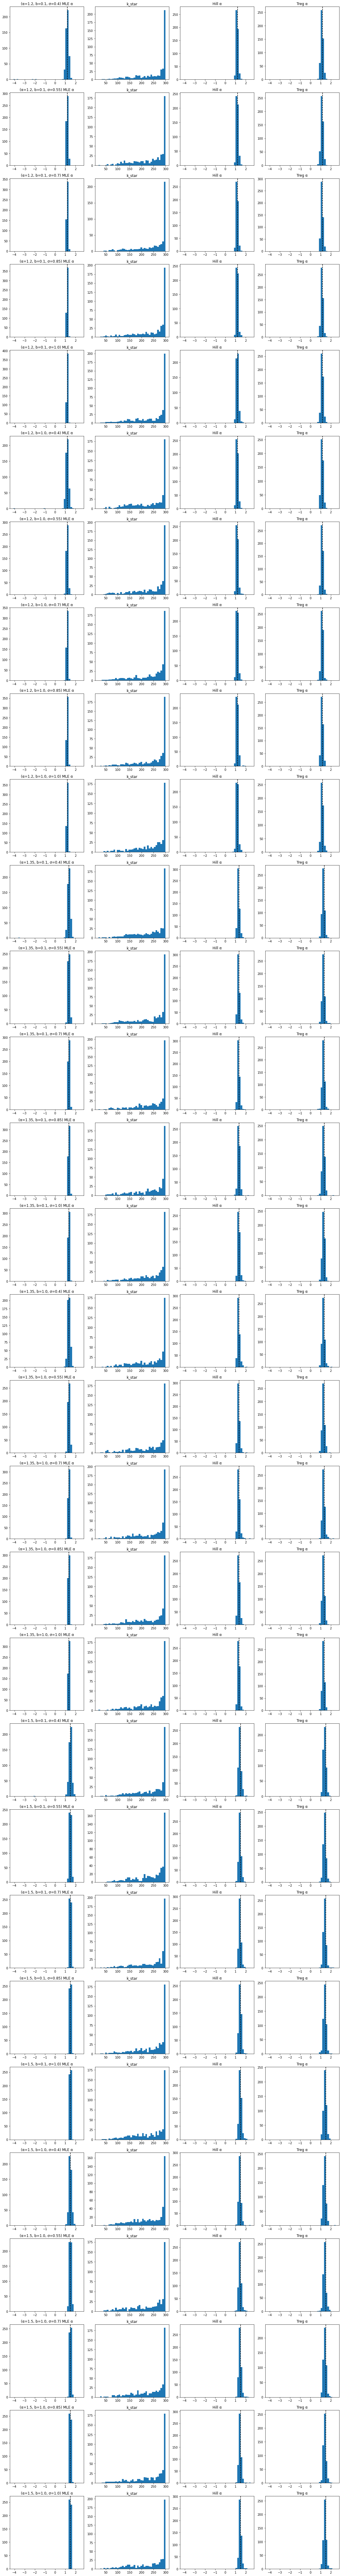

In [14]:
visualize_results(res)

### $\alpha_{MLE}, \alpha_{Hill}, \alpha_{Tail}$
Details

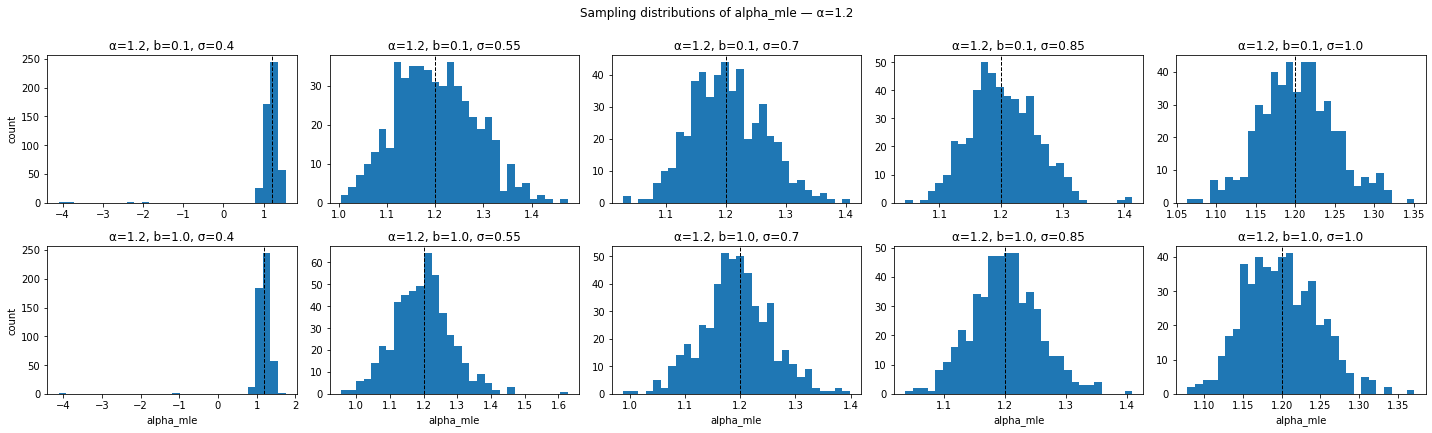

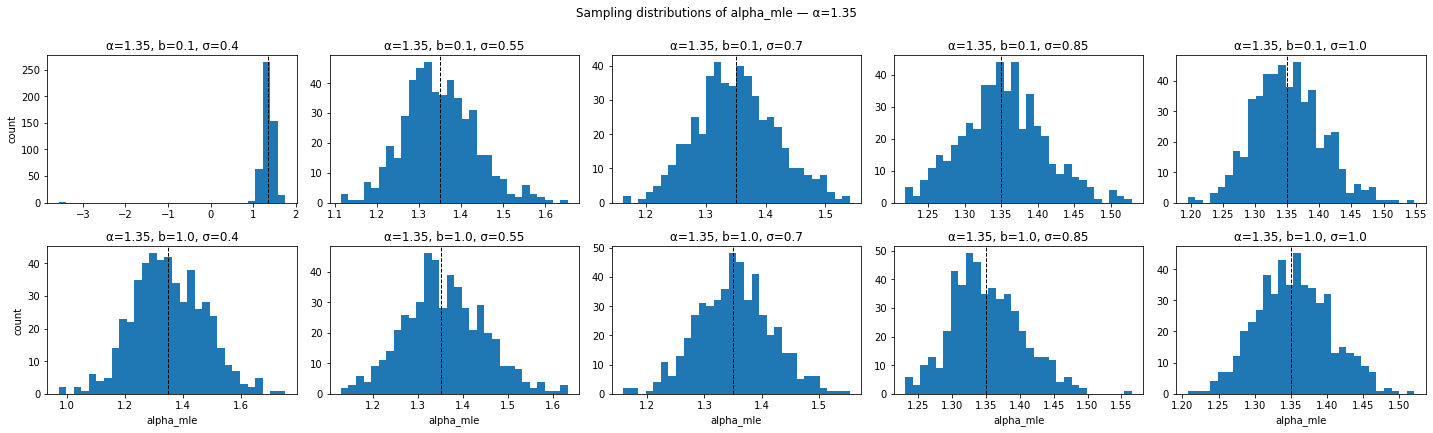

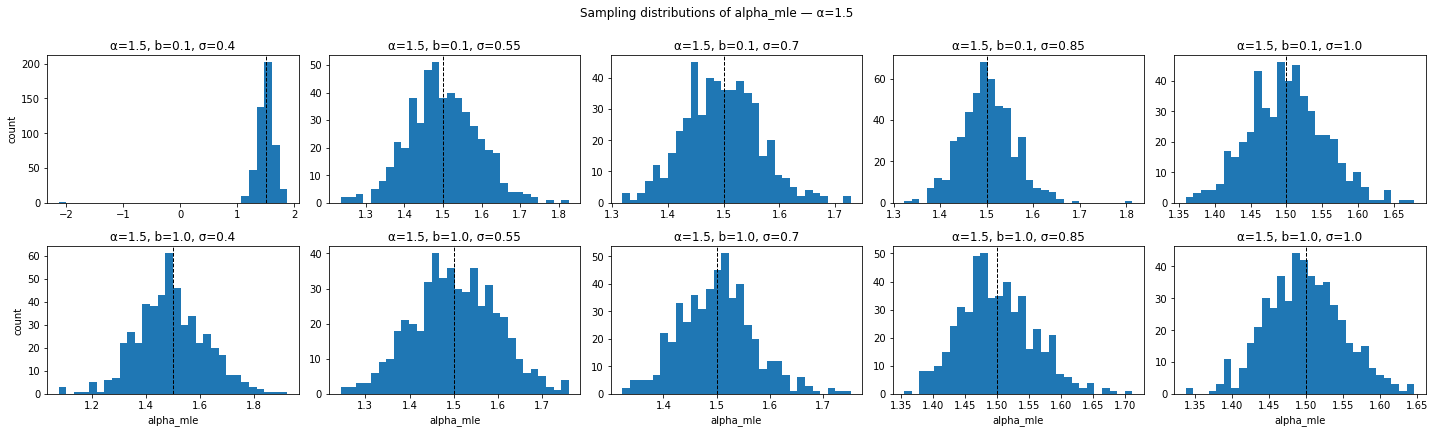

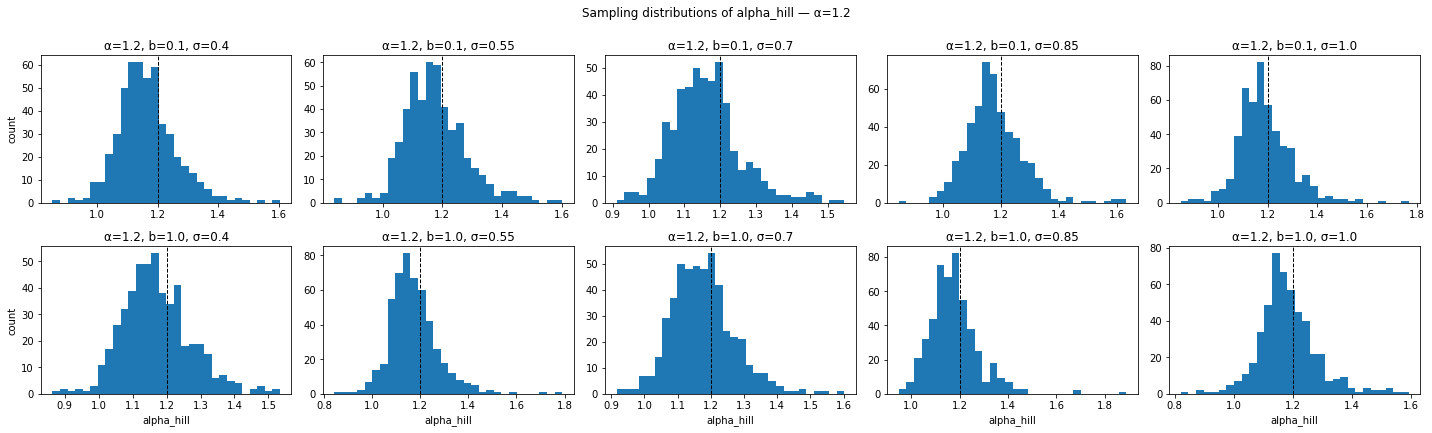

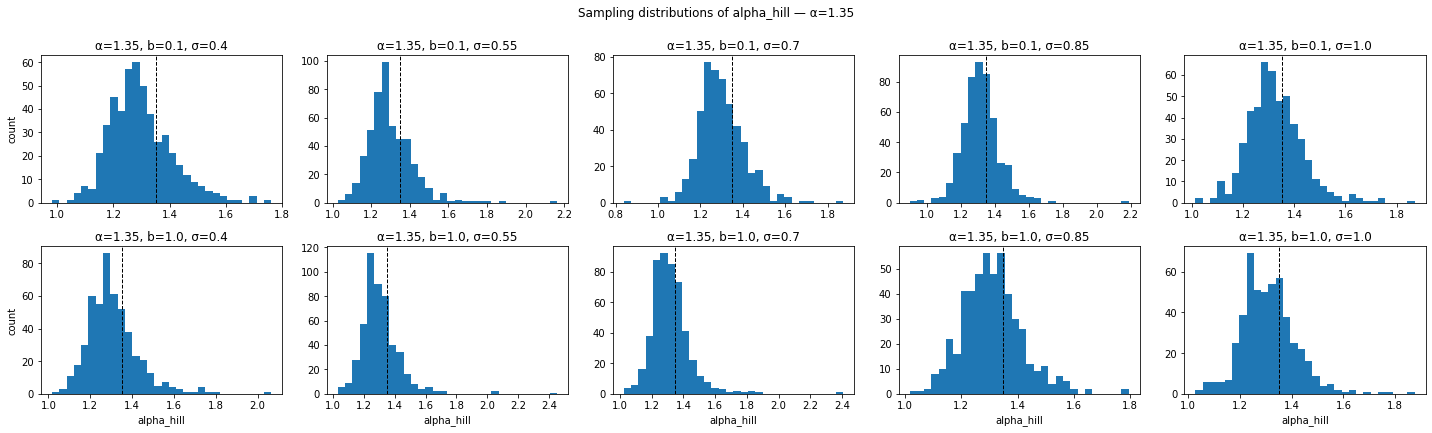

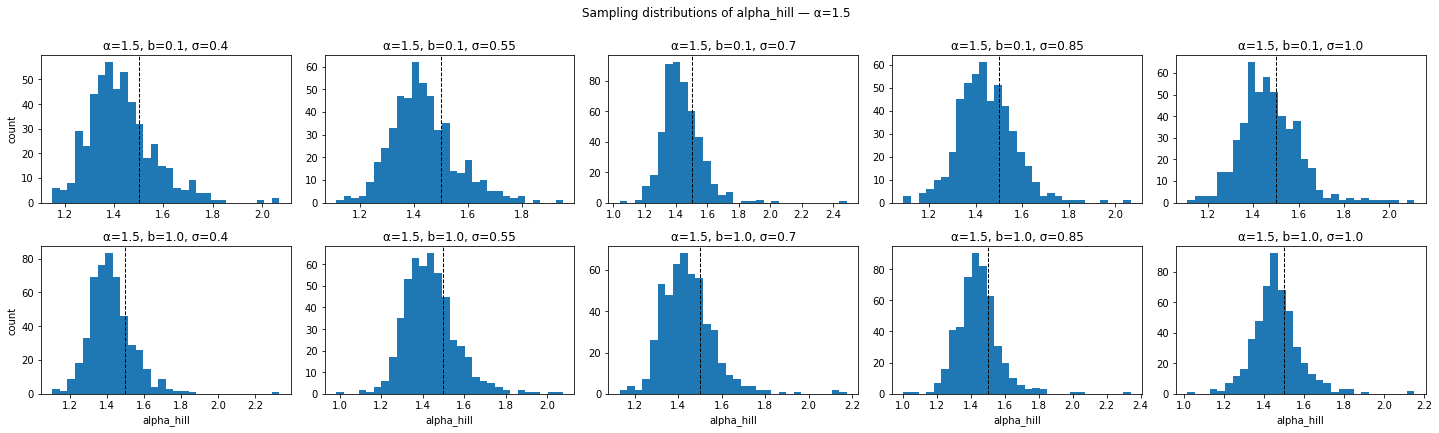

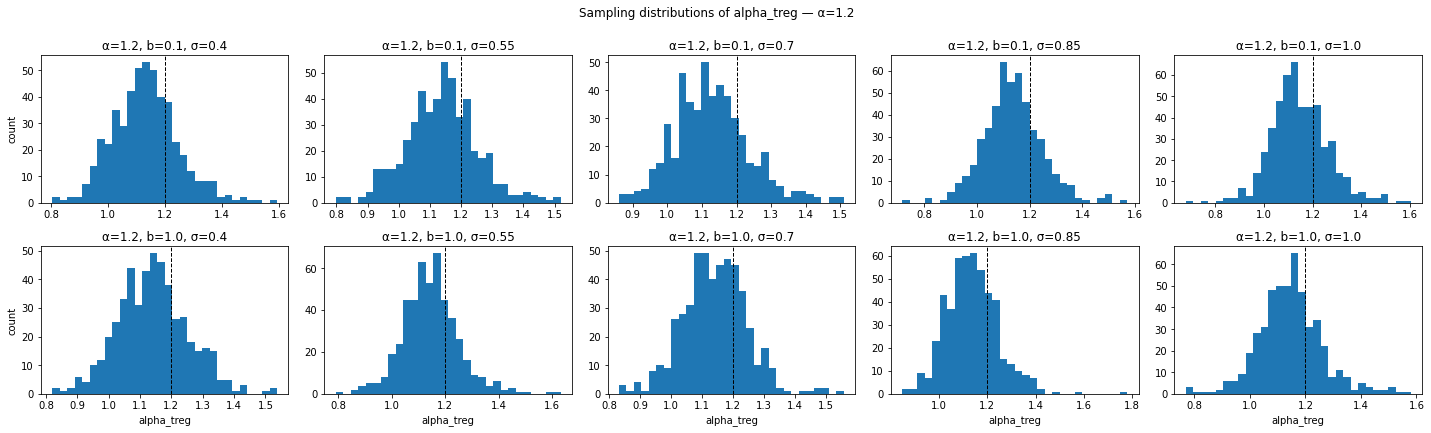

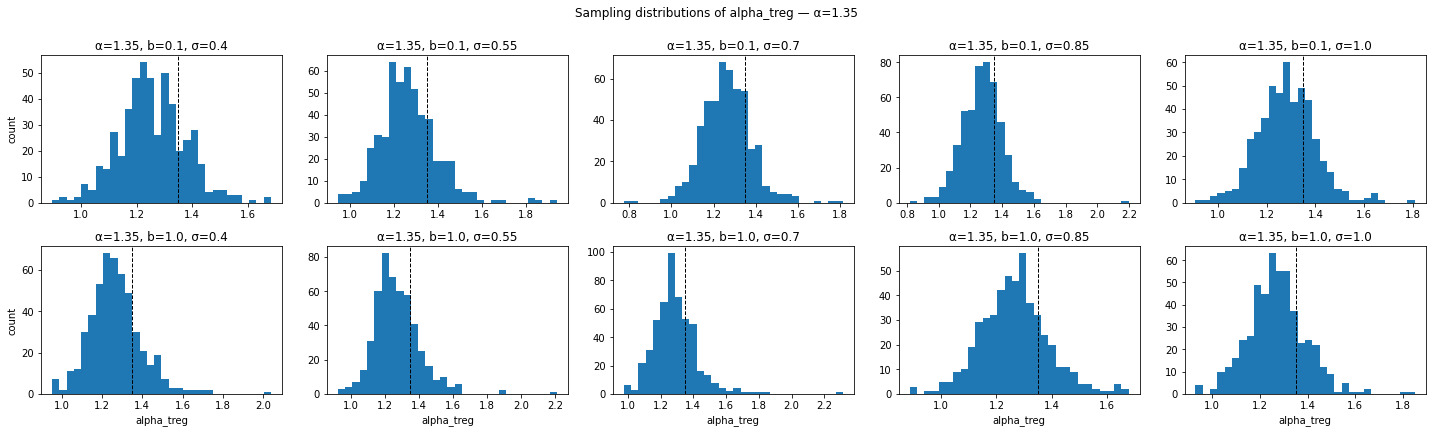

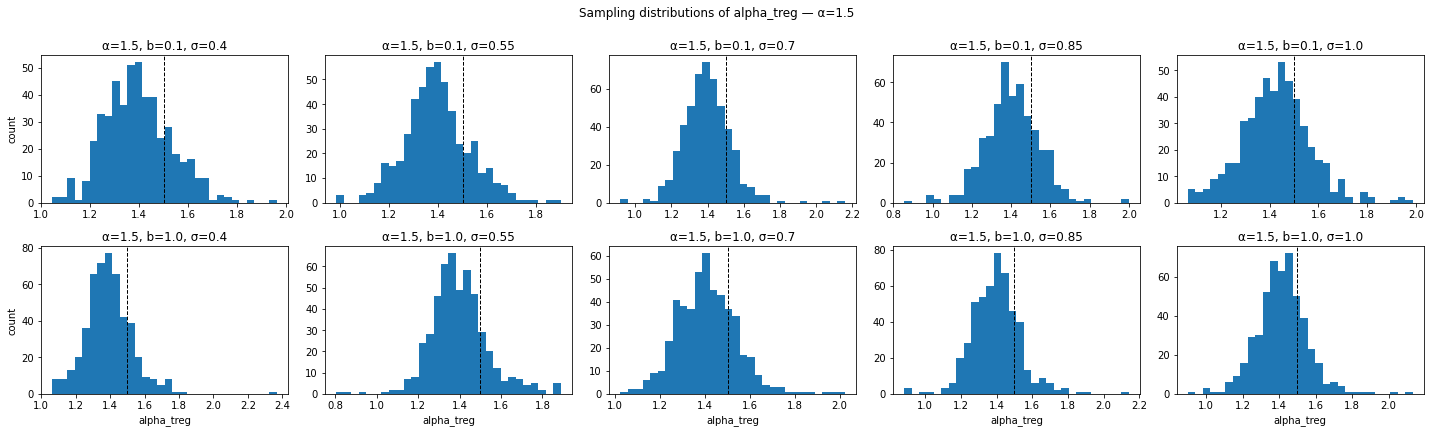

In [15]:
facet_hists(res, alpha_list, b_list, sigma_list, metric="alpha_mle")
facet_hists(res, alpha_list, b_list, sigma_list, metric="alpha_hill")
facet_hists(res, alpha_list, b_list, sigma_list, metric="alpha_treg")